# Exploratory Data Analysis

This notebook avoids profiling and avoids building the large joined tables from the original notebook. It focuses on targeted, scalable exploratory analysis for movie recommendation insights.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## Load CSV Files

In [2]:
csv_folder = Path("./movies-database")

movies       = pd.read_csv(csv_folder / "movies.csv")
links        = pd.read_csv(csv_folder / "links.csv")
ratings      = pd.read_csv(csv_folder / "ratings.csv")
tags         = pd.read_csv(csv_folder / "tags.csv")
genome_scores = pd.read_csv(csv_folder / "genome-scores.csv")
genome_tags  = pd.read_csv(csv_folder / "genome-tags.csv")

## Explorative analysis

In [3]:
movies["year"] = movies["title"].str.extract(r"\((\d{4})\)$")[0].astype("float")
ratings["rating_year"] = pd.to_datetime(ratings["timestamp"], unit="s").dt.year
tags["tag_clean"] = tags["tag"].astype("string").str.lower().str.strip()

### 1. Movie-level rating summary
Aggregate ratings once at movie level. Most later analyses use this smaller table instead of reprocessing all raw ratings.

In [4]:
movie_stats = (
    ratings.groupby("movieId")
    .agg(
        avg_rating=("rating", "mean"),
        num_ratings=("rating", "size"),
        rating_std=("rating", "std")
    )
    .reset_index()
    .merge(movies[["movieId", "title", "genres", "year"]], on="movieId", how="left")
)

movie_stats.head()

,movieId,avg_rating,num_ratings,rating_std,title,genres,year
0,1,3.893708,57309,0.921552,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0
1,2,3.251527,24228,0.959851,Jumanji (1995),Adventure|Children|Fantasy,1995.0
2,3,3.142028,11804,1.008443,Grumpier Old Men (1995),Comedy|Romance,1995.0
3,4,2.853547,2523,1.108531,Waiting to Exhale (1995),Comedy|Drama|Romance,1995.0
4,5,3.058434,11714,0.996611,Father of the Bride Part II (1995),Comedy,1995.0


### 2. Highest-rated genres
Explode genres only from the compact movie-level summary, not from the full ratings table.

In [5]:
movie_genres = movie_stats.assign(genre=movie_stats["genres"].str.split("|")).explode("genre")
movie_genres = movie_genres[movie_genres["genre"] != "(no genres listed)"]

genre_summary = (
    movie_genres.groupby("genre")
    .agg(
        avg_movie_rating=("avg_rating", "mean"),
        median_movie_rating=("avg_rating", "median"),
        avg_num_ratings=("num_ratings", "mean"),
        movie_count=("movieId", "nunique")
    )
    .reset_index()
    .sort_values("avg_movie_rating", ascending=False)
)

genre_summary

,genre,avg_movie_rating,median_movie_rating,avg_num_ratings,movie_count
6,Documentary,3.382493,3.500000,59.132404,5453
9,Film-Noir,3.318142,3.375000,708.386819,349
11,IMAX,3.252121,3.277069,5452.712821,195
17,War,3.246515,3.327108,716.014689,1770
12,Musical,3.200530,3.275000,948.133727,1017
7,Drama,3.178996,3.250000,448.102718,24465
14,Romance,3.147095,3.217391,615.645585,7305
2,Animation,3.101145,3.200000,560.284095,2911
5,Crime,3.092680,3.160192,834.048368,5024
13,Mystery,3.045787,3.074662,722.859454,2782


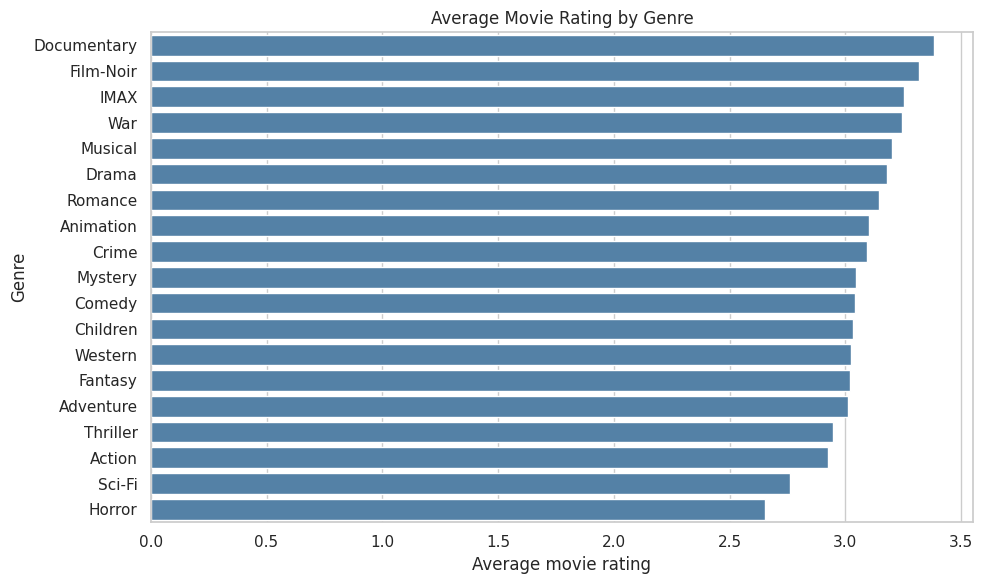

In [6]:
plt.figure(figsize=(10, 6))
sns.barplot(data=genre_summary, x="avg_movie_rating", y="genre", color="steelblue")
plt.title("Average Movie Rating by Genre")
plt.xlabel("Average movie rating")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

### 3. Most popular genres
This highlights engagement: which genres tend to attract the most ratings per movie.

In [7]:
genre_popularity = (
    movie_genres.groupby("genre")
    .agg(
        total_movies=("movieId", "nunique"),
        avg_num_ratings=("num_ratings", "mean"),
        median_num_ratings=("num_ratings", "median")
    )
    .reset_index()
    .sort_values("avg_num_ratings", ascending=False)
)

genre_popularity

,genre,total_movies,avg_num_ratings,median_num_ratings
11,IMAX,195,5452.712821,2118.0
1,Adventure,3868,1507.865564,16.0
15,Sci-Fi,3502,1235.219874,11.0
0,Action,6913,1077.233907,9.0
8,Fantasy,2667,1061.711661,12.0
12,Musical,1017,948.133727,39.0
5,Crime,5024,834.048368,10.0
16,Thriller,8330,811.917407,10.0
3,Children,2866,741.192603,8.0
13,Mystery,2782,722.859454,9.0


In [41]:
genre_combo_counts = (
    movies.groupby("genres")
    .size()
    .reset_index(name="num_movies")
    .sort_values("num_movies", ascending=False)
)

genre_combo_counts.head(20)

,genres,num_movies
1424,Drama,9056
1136,Comedy,5674
0,(no genres listed),5062
1398,Documentary,4731
1190,Comedy|Drama,2386
1507,Drama|Romance,2126
1571,Horror,1661
1294,Comedy|Romance,1577
1228,Comedy|Drama|Romance,1044
1521,Drama|Thriller,933


In [42]:

movie_stats_with_genres = ratings.groupby("movieId").agg(
    avg_rating=("rating", "mean"),
    num_ratings=("rating", "size")
).reset_index().merge(movies[["movieId", "genres"]], on="movieId", how="left")

genre_combo_summary = (
    movie_stats_with_genres.groupby("genres")
    .agg(
        num_movies=("movieId", "nunique"),
        avg_movie_rating=("avg_rating", "mean"),
        avg_num_ratings=("num_ratings", "mean")
    )
    .reset_index()
    .sort_values("num_movies", ascending=False)
)

genre_combo_summary.head(20)

,genres,num_movies,avg_movie_rating,avg_num_ratings
1406,Drama,8637,3.216112,204.434989
1125,Comedy,5291,2.977916,285.897184
1380,Documentary,4603,3.392415,51.049533
0,(no genres listed),4568,3.048613,5.829028
1178,Comedy|Drama,2312,3.204235,312.038062
1489,Drama|Romance,2006,3.217268,396.976570
1553,Horror,1556,2.545332,119.880463
1279,Comedy|Romance,1464,3.057254,616.155055
1214,Comedy|Drama|Romance,1014,3.209647,705.886588
1503,Drama|Thriller,895,3.052101,408.888268


### 4. Best popular movies
Restrict to movies with many ratings so that the list reflects broad audience approval rather than tiny samples.

In [8]:
best_movies = (
    movie_stats[movie_stats["num_ratings"] >= 1000]
    .sort_values(["avg_rating", "num_ratings"], ascending=[False, False])
    [["title", "year", "genres", "avg_rating", "num_ratings"]]
)

best_movies.head(20)

,title,year,genres,avg_rating,num_ratings
42953,Planet Earth II (2016),2016.0,Documentary,4.483096,1124
38361,Planet Earth (2006),2006.0,Documentary,4.464797,1747
314,"Shawshank Redemption, The (1994)",1994.0,Crime|Drama,4.413576,81482
42806,Band of Brothers (2001),2001.0,Action|Drama|War,4.398599,1356
840,"Godfather, The (1972)",1972.0,Crime|Drama,4.324336,52498
49,"Usual Suspects, The (1995)",1995.0,Crime|Mystery|Thriller,4.284353,55366
1190,"Godfather: Part II, The (1974)",1974.0,Crime|Drama,4.261759,34188
1930,Seven Samurai (Shichinin no samurai) (1954),1954.0,Action|Adventure|Drama,4.254769,13367
522,Schindler's List (1993),1993.0,Drama|War,4.247579,60411
1173,12 Angry Men (1957),1957.0,Drama,4.243014,16569


### 5. Most divisive popular movies
High standard deviation suggests polarizing audience reactions.

In [9]:
divisive_movies = (
    movie_stats[movie_stats["num_ratings"] >= 1000]
    .sort_values("rating_std", ascending=False)
    [["title", "genres", "avg_rating", "rating_std", "num_ratings"]]
)

divisive_movies.head(20)

,title,genres,avg_rating,rating_std,num_ratings
18787,"Twilight Saga: Breaking Dawn - Part 2, The (2012)",Adventure|Drama|Fantasy|Romance|IMAX,2.524219,1.456004,1569
17344,"Twilight Saga: Breaking Dawn - Part 1, The (2011)",Adventure|Drama|Fantasy|Romance,2.328586,1.442347,1896
1835,Plan 9 from Outer Space (1959),Horror|Sci-Fi,2.613348,1.417228,2210
14856,"Twilight Saga: Eclipse, The (2010)",Fantasy|Romance|Thriller|IMAX,2.377319,1.405303,2857
10859,High School Musical (2006),Children|Comedy|Drama|Musical|Romance,2.584979,1.377933,1165
13985,"Twilight Saga: New Moon, The (2009)",Drama|Fantasy|Horror|Romance|Thriller,2.351161,1.377465,2842
12821,Twilight (2008),Drama|Fantasy|Romance|Thriller,2.391415,1.359245,6115
4151,Freddy Got Fingered (2001),Comedy,2.140616,1.354680,1721
25638,Fifty Shades of Grey (2015),Drama|Romance,2.020944,1.340667,1313
7849,White Chicks (2004),Action|Comedy|Crime,2.397964,1.331088,2112


### 6. Ratings activity over time
Shows how user engagement and average rating behavior changed over the years when ratings were submitted.

In [10]:
ratings_by_year = (
    ratings.groupby("rating_year")
    .agg(
        total_ratings=("rating", "size"),
        avg_rating=("rating", "mean"),
        unique_users=("userId", "nunique"),
        unique_movies=("movieId", "nunique")
    )
    .reset_index()
    .sort_values("rating_year")
)

ratings_by_year

,rating_year,total_ratings,avg_rating,unique_users,unique_movies
0,1995,3,3.666667,1,3
1,1996,1430093,3.545700,23028,1383
2,1997,626202,3.587665,10014,1672
3,1998,272099,3.512791,3315,2295
4,1999,1059080,3.616826,8387,3026
5,2000,1735398,3.575065,13303,3861
6,2001,1058750,3.532356,9300,4712
7,2002,776654,3.485714,7098,5722
8,2003,920295,3.476976,7674,6806
9,2004,1048116,3.430770,7842,7980


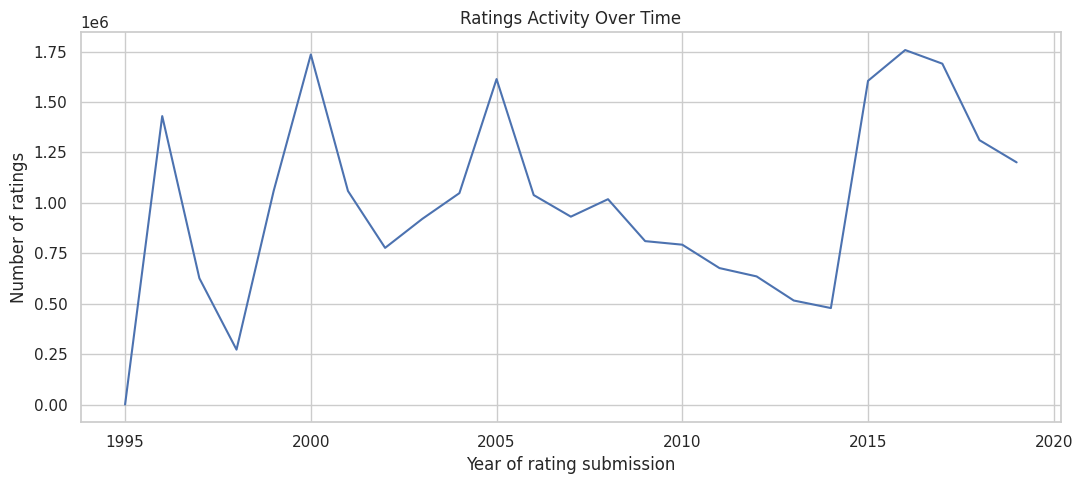

In [11]:
plt.figure(figsize=(11, 5))
sns.lineplot(data=ratings_by_year, x="rating_year", y="total_ratings")
plt.title("Ratings Activity Over Time")
plt.xlabel("Year of rating submission")
plt.ylabel("Number of ratings")
plt.tight_layout()
plt.show()

### 7. Most-tagged movies
Tags provide useful qualitative signals about what viewers notice and talk about.

In [12]:
tagged_movies = (
    tags.groupby("movieId")
    .agg(
        num_tags=("tag", "size"),
        unique_taggers=("userId", "nunique"),
        unique_tags=("tag_clean", "nunique")
    )
    .reset_index()
    .merge(movies[["movieId", "title", "genres"]], on="movieId", how="left")
    .sort_values("num_tags", ascending=False)
)

tagged_movies.head(20)

,movieId,num_tags,unique_taggers,unique_tags,title,genres
248,260,6180,2177,707,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
281,296,4767,944,500,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
14238,79132,4767,622,211,Inception (2010),Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX
19718,109487,3616,482,226,Interstellar (2014),Sci-Fi|IMAX
2708,2959,3612,645,249,Fight Club (1999),Action|Crime|Drama|Thriller
302,318,3597,743,384,"Shawshank Redemption, The (1994)",Crime|Drama
2335,2571,3573,597,282,"Matrix, The (1999)",Action|Sci-Fi|Thriller
339,356,2701,679,523,Forrest Gump (1994),Comedy|Drama|Romance|War
3910,4226,2601,487,174,Memento (2000),Mystery|Thriller
6903,7361,2533,465,188,Eternal Sunshine of the Spotless Mind (2004),Drama|Romance|Sci-Fi


### 8. Most common tags
These are recurring audience descriptors that may later become useful recommendation features.

In [13]:
common_tags = (
    tags.groupby("tag_clean")
    .agg(
        count=("tag_clean", "size"),
        unique_movies=("movieId", "nunique")
    )
    .reset_index()
    .sort_values("count", ascending=False)
)

common_tags.head(30)

,tag_clean,count,unique_movies
50543,sci-fi,8795,558
4449,atmospheric,7053,659
1181,action,6783,978
12377,comedy,6368,1624
56307,surreal,5584,576
22589,funny,5354,1165
5890,based on a book,5194,1395
60074,twist ending,4904,297
61876,visually appealing,4691,346
49191,romance,4482,1296


### 9. Common tags associated with higher ratings
Restrict to common tags to keep the analysis more robust and more computationally manageable.

In [39]:
ratings_sample = ratings.sample(2_000_000, random_state=42)

popular_tag_names = common_tags.loc[common_tags["count"] >= 100, "tag_clean"]
tags_small = tags[tags["tag_clean"].isin(popular_tag_names)].copy()

tag_rating = (
    tags_small.merge(
        ratings_sample[["userId", "movieId", "rating"]],
        on=["userId", "movieId"],
        how="inner"
    )
    .groupby("tag_clean")
    .agg(
        avg_rating=("rating", "mean"),
        num_tagged_ratings=("rating", "size"),
        unique_movies=("movieId", "nunique")
    )
    .reset_index()
    .sort_values("avg_rating", ascending=False)
)
tag_rating.head(30)

,tag_clean,avg_rating,num_tagged_ratings,unique_movies
484,eroticism,5.000000,1,1
982,must see,5.000000,3,3
213,brainwashing,5.000000,1,1
522,favorite,4.916667,6,6
437,drug dealer,4.833333,3,3
1527,vigilantism,4.812500,8,3
1268,secret agent,4.750000,2,2
615,good science,4.700000,10,1
904,masterpiece,4.693182,44,16
1397,super power,4.666667,3,3


### 10. Ratings by release decade
This shows whether older or newer movie eras tend to receive stronger average ratings.

In [15]:
decade_summary = (
    movie_stats.dropna(subset=["year"])
    .assign(decade=lambda df: (df["year"] // 10 * 10).astype(int))
    .groupby("decade")
    .agg(
        avg_movie_rating=("avg_rating", "mean"),
        avg_num_ratings=("num_ratings", "mean"),
        movie_count=("movieId", "nunique")
    )
    .reset_index()
    .sort_values("decade")
)

decade_summary

,decade,avg_movie_rating,avg_num_ratings,movie_count
0,1870,2.968434,20.000000,2
1,1880,2.363600,12.714286,7
2,1890,2.634656,8.166667,108
3,1900,2.941915,10.917241,145
4,1910,2.840592,12.420601,233
5,1920,3.174711,71.848030,533
6,1930,3.018591,115.596292,1672
7,1940,3.122109,155.399284,1956
8,1950,3.115313,193.804059,2562
9,1960,3.142487,224.918380,3259


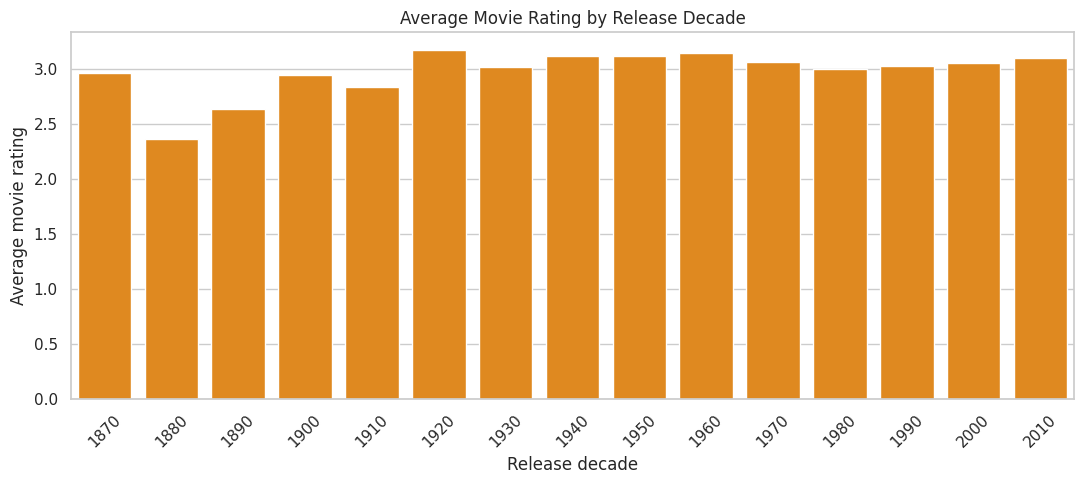

In [16]:
plt.figure(figsize=(11, 5))
sns.barplot(data=decade_summary, x="decade", y="avg_movie_rating", color="darkorange")
plt.title("Average Movie Rating by Release Decade")
plt.xlabel("Release decade")
plt.ylabel("Average movie rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Rating distribution


In [17]:
movie_rating_counts = (
    ratings.groupby("movieId")
    .size()
    .reset_index(name="num_ratings")
)

movie_rating_counts["num_ratings"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count    59047.000000
mean       423.393144
std       2477.885821
min          1.000000
50%          6.000000
75%         36.000000
90%        413.000000
95%       1503.400000
99%       9941.620000
max      81491.000000
Name: num_ratings, dtype: float64

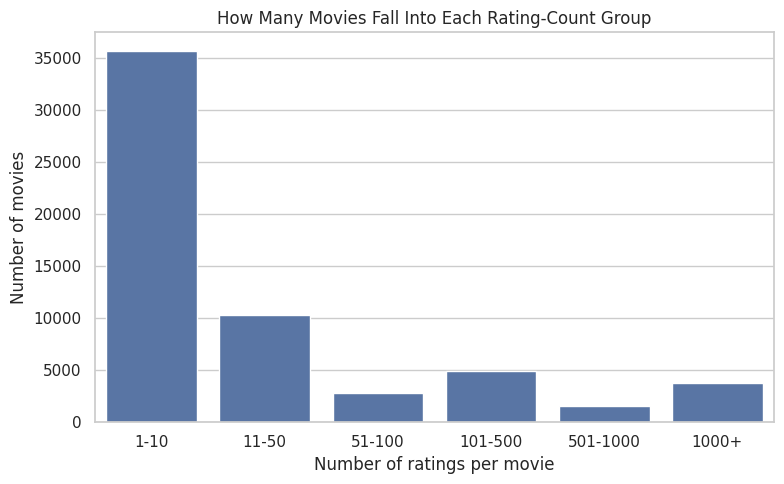

In [22]:
bins = [0, 10, 50, 100, 500, 1000, movie_rating_counts["num_ratings"].max()]
labels = ["1-10", "11-50", "51-100", "101-500", "501-1000", "1000+"]

movie_rating_counts["bucket"] = pd.cut(
    movie_rating_counts["num_ratings"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

bucket_summary = movie_rating_counts["bucket"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=bucket_summary.index, y=bucket_summary.values)
plt.title("How Many Movies Fall Into Each Rating-Count Group")
plt.xlabel("Number of ratings per movie")
plt.ylabel("Number of movies")
plt.tight_layout()
plt.show()

In [19]:
movie_rating_counts = movie_rating_counts.sort_values("num_ratings", ascending=False).reset_index(drop=True)
movie_rating_counts["cum_ratings_share"] = movie_rating_counts["num_ratings"].cumsum() / movie_rating_counts["num_ratings"].sum()
movie_rating_counts["cum_movie_share"] = (movie_rating_counts.index + 1) / len(movie_rating_counts)

movie_rating_counts.head()

,movieId,num_ratings,cum_ratings_share,cum_movie_share
0,356,81491,0.003260,0.000017
1,318,81482,0.006519,0.000034
2,296,79672,0.009706,0.000051
3,593,74127,0.012671,0.000068
4,2571,72674,0.015578,0.000085


In [23]:
movie_rating_counts = ratings.groupby("movieId").size().reset_index(name="num_ratings")
movie_rating_counts = movie_rating_counts.sort_values("num_ratings", ascending=False).reset_index(drop=True)

summary_table = pd.DataFrame({
    "group": ["Top 1% movies", "Top 5% movies", "Top 10% movies", "Bottom 90% movies"],
    "share_of_all_ratings": [
        movie_rating_counts.iloc[:max(1, int(0.01 * len(movie_rating_counts)))]["num_ratings"].sum() / movie_rating_counts["num_ratings"].sum(),
        movie_rating_counts.iloc[:max(1, int(0.05 * len(movie_rating_counts)))]["num_ratings"].sum() / movie_rating_counts["num_ratings"].sum(),
        movie_rating_counts.iloc[:max(1, int(0.10 * len(movie_rating_counts)))]["num_ratings"].sum() / movie_rating_counts["num_ratings"].sum(),
        movie_rating_counts.iloc[max(1, int(0.10 * len(movie_rating_counts))):]["num_ratings"].sum() / movie_rating_counts["num_ratings"].sum()
    ]
})

summary_table

,group,share_of_all_ratings
0,Top 1% movies,0.475913
1,Top 5% movies,0.844548
2,Top 10% movies,0.940211
3,Bottom 90% movies,0.059789


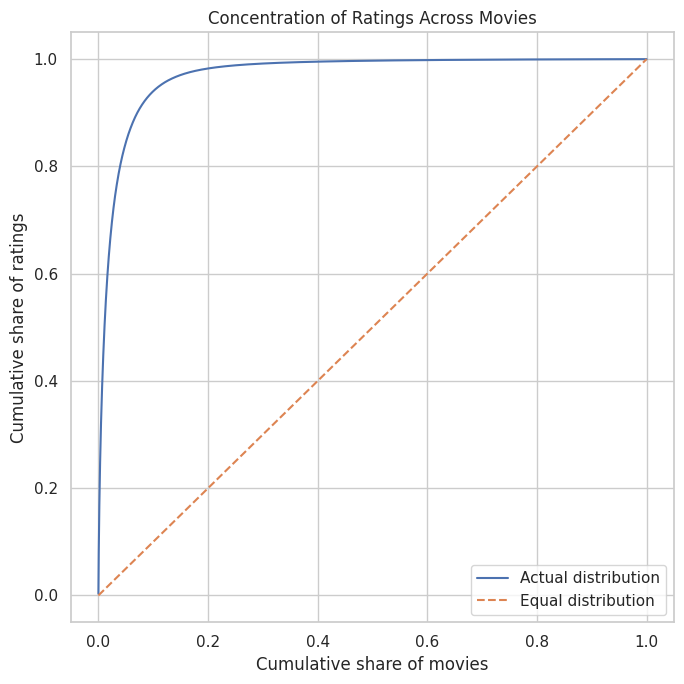

In [24]:
movie_rating_counts["cum_ratings_share"] = movie_rating_counts["num_ratings"].cumsum() / movie_rating_counts["num_ratings"].sum()
movie_rating_counts["cum_movie_share"] = (movie_rating_counts.index + 1) / len(movie_rating_counts)

plt.figure(figsize=(7, 7))
plt.plot(movie_rating_counts["cum_movie_share"], movie_rating_counts["cum_ratings_share"], label="Actual distribution")
plt.plot([0, 1], [0, 1], linestyle="--", label="Equal distribution")
plt.title("Concentration of Ratings Across Movies")
plt.xlabel("Cumulative share of movies")
plt.ylabel("Cumulative share of ratings")
plt.legend()
plt.tight_layout()
plt.show()

# Sparse Ratings

In [25]:
user_rating_counts = ratings.groupby("userId").size().reset_index(name="num_ratings")

user_sparsity_table = pd.DataFrame({
    "group": ["Users with <= 10 ratings", "Users with <= 20 ratings", "Users with <= 50 ratings", "Users with > 100 ratings"],
    "share_of_users": [
        (user_rating_counts["num_ratings"] <= 10).mean(),
        (user_rating_counts["num_ratings"] <= 20).mean(),
        (user_rating_counts["num_ratings"] <= 50).mean(),
        (user_rating_counts["num_ratings"] > 100).mean()
    ]
})

user_sparsity_table

,group,share_of_users
0,Users with <= 10 ratings,0.000000
1,Users with <= 20 ratings,0.028368
2,Users with <= 50 ratings,0.378163
3,Users with > 100 ratings,0.388222


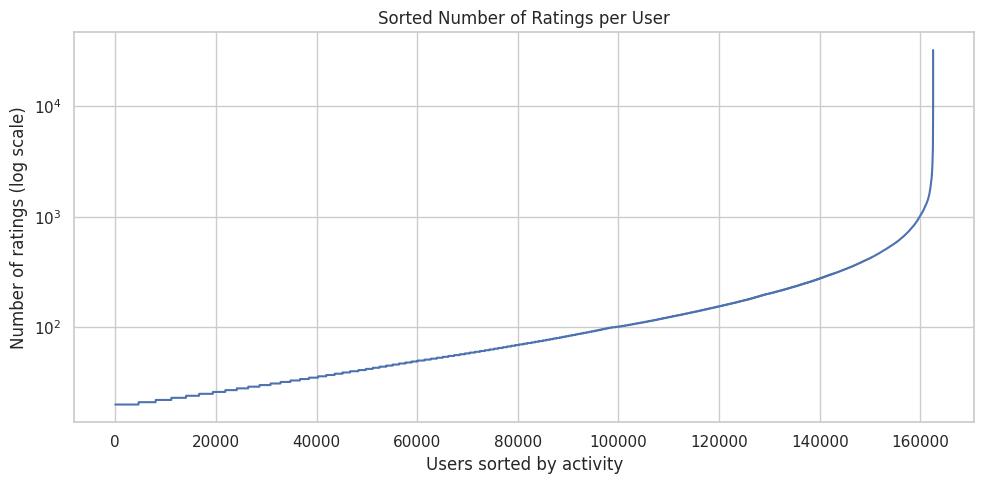

In [26]:
user_rating_counts_sorted = user_rating_counts["num_ratings"].sort_values().reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.plot(user_rating_counts_sorted.values)
plt.yscale("log")
plt.title("Sorted Number of Ratings per User")
plt.xlabel("Users sorted by activity")
plt.ylabel("Number of ratings (log scale)")
plt.tight_layout()
plt.show()

# Usefullness of tags?

In [27]:
movie_tag_counts = tags.groupby("movieId").agg(
    total_tags=("tag", "size"),
    unique_tags=("tag", "nunique")
).reset_index()

metadata_table = pd.DataFrame({
    "group": ["Movies with at least 1 tag", "Movies with at least 5 tags", "Movies with at least 10 unique tags"],
    "share_of_movies": [
        movies["movieId"].isin(movie_tag_counts["movieId"]).mean(),
        movies["movieId"].isin(movie_tag_counts.loc[movie_tag_counts["total_tags"] >= 5, "movieId"]).mean(),
        movies["movieId"].isin(movie_tag_counts.loc[movie_tag_counts["unique_tags"] >= 10, "movieId"]).mean()
    ]
})

metadata_table

,group,share_of_movies
0,Movies with at least 1 tag,0.724909
1,Movies with at least 5 tags,0.392131
2,Movies with at least 10 unique tags,0.212998


# Movies with sparse but good ratings

In [29]:
movie_stats_simple = ratings.groupby("movieId").agg(
    avg_rating=("rating", "mean"),
    num_ratings=("rating", "size")
).reset_index().merge(movies[["movieId", "title"]], on="movieId", how="left")

small_sample_table = movie_stats_simple.sort_values(
    ["avg_rating", "num_ratings"], ascending=[False, True]
)[["title", "avg_rating", "num_ratings"]].head(20)

small_sample_table

,title,avg_rating,num_ratings
9414,"Hijacking Catastrophe: 9/11, Fear & the Sellin...",5.0,1
9640,Always a Bridesmaid (2000),5.0,1
15755,Deadly Delicious (Shuang Shi Ji) (2008),5.0,1
16444,As Seen Through These Eyes (2008),5.0,1
17745,Latin Music USA (2009),5.0,1
17972,"Eye for an Eye, An (Silmä silmästä) (1999)",5.0,1
18206,Joffrey: Mavericks of American Dance (2012),5.0,1
18472,Puckoon (2002),5.0,1
18999,"Parasites, Les (1999)",5.0,1
19994,Iran Is Not the Problem (2008),5.0,1


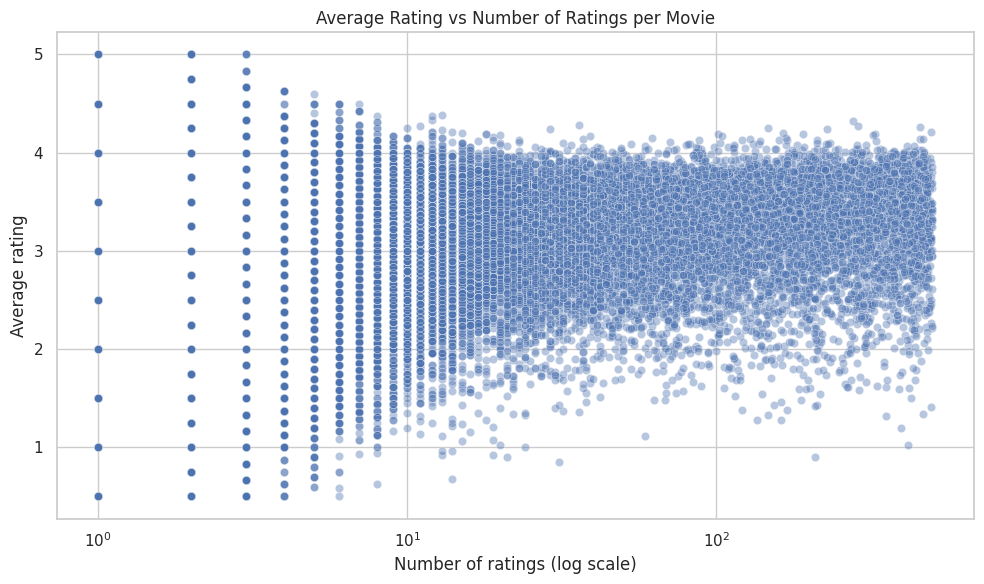

In [30]:
plot_sample = movie_stats_simple[movie_stats_simple["num_ratings"] <= 500]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_sample, x="num_ratings", y="avg_rating", alpha=0.4)
plt.xscale("log")
plt.title("Average Rating vs Number of Ratings per Movie")
plt.xlabel("Number of ratings (log scale)")
plt.ylabel("Average rating")
plt.tight_layout()
plt.show()

# Movies with no genre listed

In [36]:
movie_stats_simple = (
    ratings.groupby("movieId")
    .agg(num_ratings=("rating", "size"))
    .reset_index()
)

most_rated_no_genre_movie = (
    movies[movies["genres"] == "(no genres listed)"]
    .merge(movie_stats_simple, on="movieId", how="left")
    .sort_values("num_ratings", ascending=False)
)

most_rated_no_genre_movie.head(10)

,movieId,title,genres,year,num_ratings
64,122896,Pirates of the Caribbean: Dead Men Tell No Tal...,(no genres listed),2017.0,1687.0
3965,183869,Hereditary (2018),(no genres listed),2018.0,1313.0
1187,141866,Green Room (2015),(no genres listed),2015.0,1060.0
2977,166024,Whiplash (2013),(no genres listed),2013.0,1030.0
780,135426,Fantastic Beasts and Where to Find Them 2 (2018),(no genres listed),2018.0,891.0
2374,156605,Paterson,(no genres listed),NaN,571.0
3994,184399,Eighth Grade (2018),(no genres listed),2018.0,544.0
3583,176601,Black Mirror,(no genres listed),NaN,456.0
974,138212,Spectral (2016),(no genres listed),2016.0,430.0
1277,143387,Pitch Perfect 3 (2017),(no genres listed),2017.0,304.0
